# Demo: ThresholdPlot

This notebook is the primary reference for `ThresholdPlot` and includes compact examples for all main features.

In [1]:
import matplotlib.pyplot as plt

from pythermalcomfort.models import (
    adaptive_ashrae,
    adaptive_en,
    heat_index_rothfusz,
    pmv_ppd_ashrae,
    pmv_ppd_iso,
    utci,
)
from pythermalcomfort.plots.matplotlib import (
    AdaptivePlot,
    PsychrometricPlot,
    RegionsConfig,
    ThresholdPlot,
)

## 1. Basic PMV Threshold Plot

Define x/y axes and their resolution, fixed model inputs, output thresholds, then render.

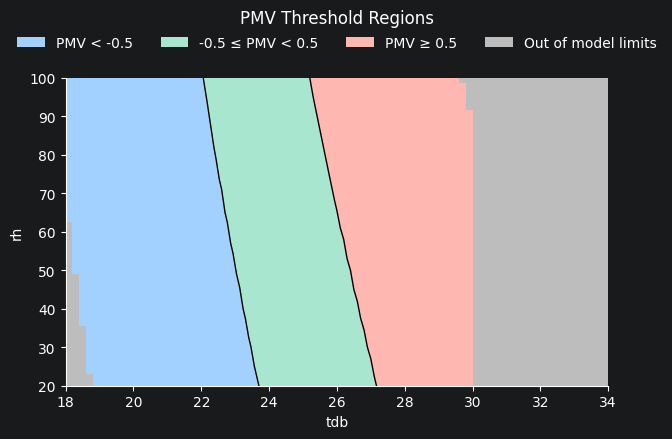

In [2]:
pmv_result = (
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 34.0, resolution=0.2)
    .set_y_axis("rh", 20.0, 100.0, resolution=0.5)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(title="PMV Threshold Regions")
)

## 2. Custom Region Labels and Colors

In [3]:
pmv_custom = (
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 32.0, resolution=0.5)
    .set_y_axis("rh", 20.0, 100.0, resolution=10)
    .set_params(vr=0.20, met=1.2, clo=0.5, wme=0.0)
    .set_regions(
        output="pmv",
        thresholds=[-0.5, 0.5],
        labels=["Cold", "Neutral", "Hot"],
        colors=["#4c78a8", "#d9d9d9", "#c9415f"],
    )
    .plot(title="PMV Regions (Custom Labels and Colors)")
)

## 3. Line, Fill, and Legend Styling

Use `line_kws`, `fill_kws`, and `legend_kws` for quick visual customization.

In [4]:
styled_result = (
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 34.0, resolution=0.2)
    .set_y_axis("rh", 20.0, 100.0, resolution=0.5)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(
        title="Styled Threshold Plot",
        line_kws={"color": "black", "linewidth": 2.0, "linestyle": "dashed"},
        fill_kws={"alpha": 0.70},
        legend_kws={
            "title": "PMV bands",
            "ncol": 1,
            "loc": "right",
            "bbox_to_anchor": (0.5, 0.0, 0.5, 0.5),
        },
    )
)

## 4. Invalid Region Rendering (`invalid_color`)

Customize how out-of-model cells are displayed in both plot and legend.

In [5]:
invalid_color_result = (
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 10.0, 40.0, resolution=0.5)
    .set_y_axis("rh", 0.0, 100.0, resolution=0.5)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(title="Out-of-Model Color Example", invalid_color="#8c8c8c")
)

## 5. Legend, Boundary-Line, and Model Input Toggles

`legend=False` and `show_lines=False` control plot decorations.  `limit_inputs=False` is a **model-level** parameter passed via `set_params` — it disables the model's own applicability-range check, which is useful when you want to visualise conditions outside the standard's defined limits.

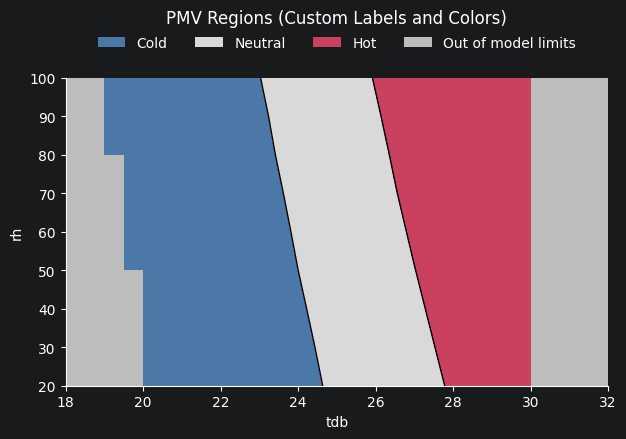

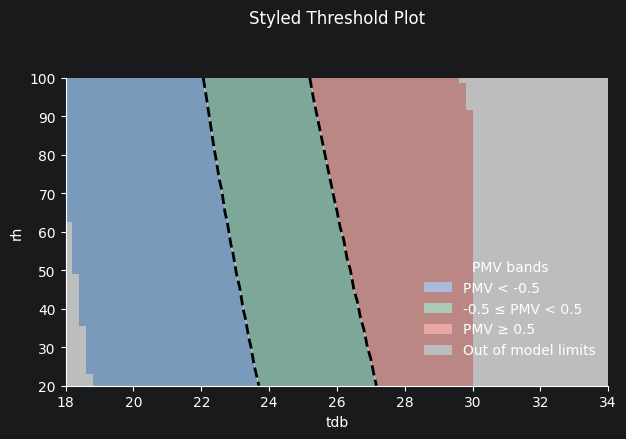

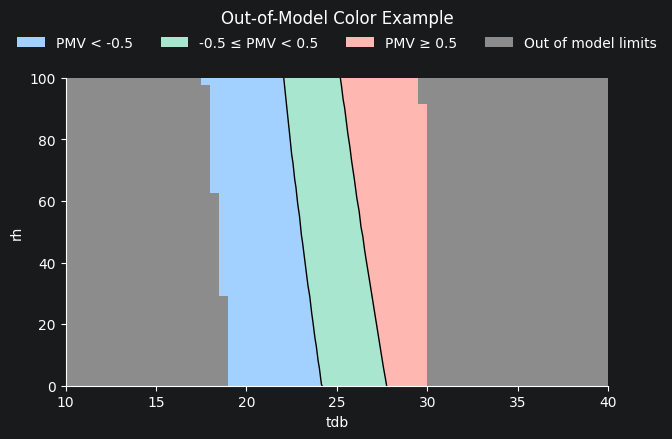

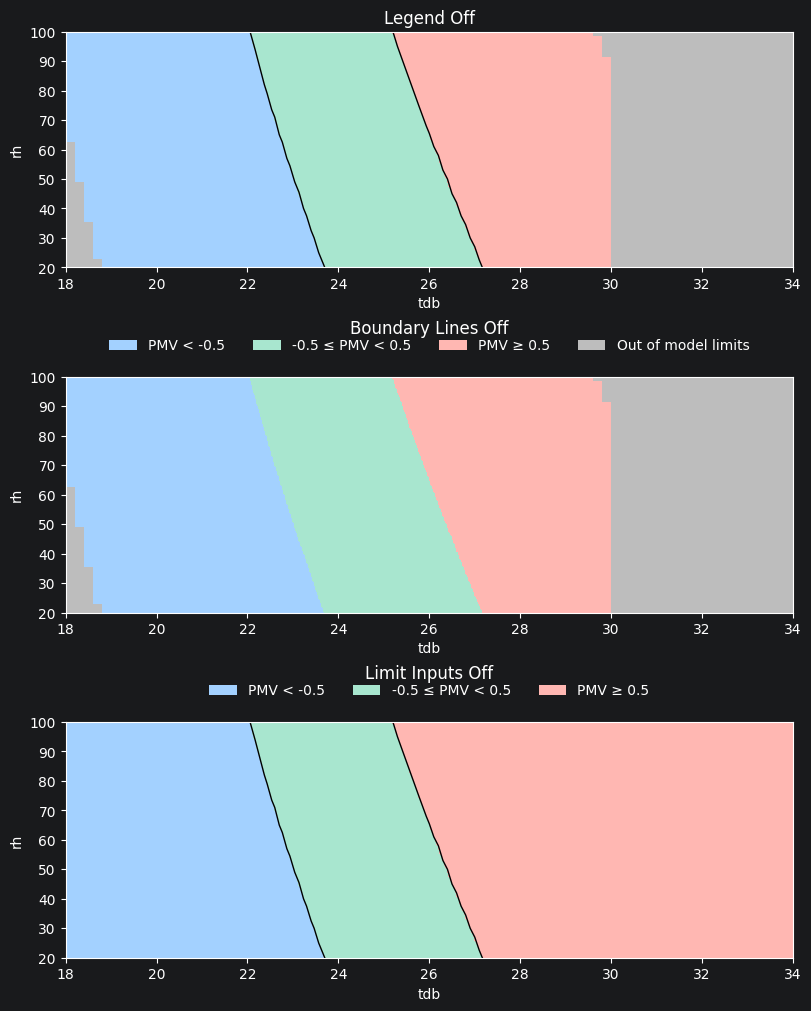

In [6]:
fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(8, 10), constrained_layout=True)

(
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 34.0, resolution=0.2)
    .set_y_axis("rh", 20.0, 100.0, resolution=0.5)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=ax0, title="Legend Off", legend=False)
)

(
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 34.0, resolution=0.2)
    .set_y_axis("rh", 20.0, 100.0, resolution=0.5)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=ax1, title="Boundary Lines Off", show_lines=False)
)

(
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 34.0, resolution=0.2)
    .set_y_axis("rh", 20.0, 100.0, resolution=0.5)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0, limit_inputs=False)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=ax2, title="Limit Inputs Off")
)

plt.show()

## 6. Artist-Level Customization After Plot

Returned artists can be modified directly.

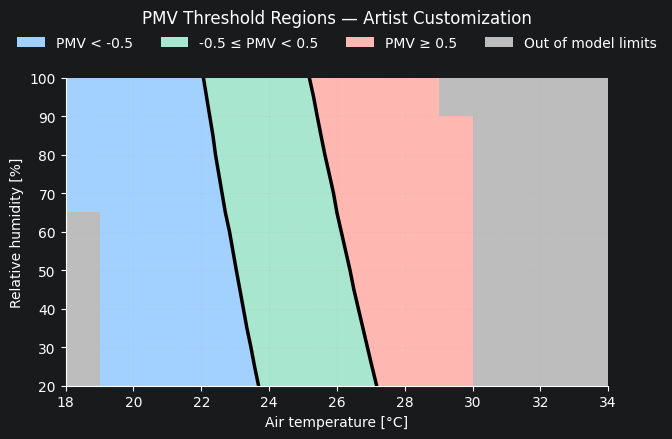

In [7]:
artist_result = (
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 34.0, resolution=1)
    .set_y_axis("rh", 20.0, 100.0, resolution=5)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(title="PMV Threshold Regions — Artist Customization")
)

for line in artist_result.lines:
    line.set_linewidth(2.5)

artist_result.ax.set_xlabel("Air temperature [°C]")
artist_result.ax.set_ylabel("Relative humidity [%]")
artist_result.ax.grid(alpha=0.15)
plt.show()

## 7. UTCI Example

In [8]:
utci_result = (
    ThresholdPlot(utci)
    .set_x_axis("tdb", 10.0, 40.0, resolution=1.0)
    .set_y_axis("rh", 20.0, 100.0, resolution=0.5)
    .set_params(v=1.0)  # tr omitted — auto-linked to tdb (see section 11)
    .set_regions(
        output="utci",
        thresholds=[26, 32],
        labels=["Cool", "Comfortable", "Hot"],
        colors=["#4c78a8", "#d9d9d9", "#c9415f"],
    )
    .plot(title="UTCI Threshold Regions")
)

utci_result.ax.set_xlabel("Air temperature [°C]")
utci_result.ax.set_ylabel("Relative humidity [%]")

Text(0, 0.5, 'Relative humidity [%]')

## 8. Heat Index Example

In [9]:
hi_result = (
    ThresholdPlot(heat_index_rothfusz)
    .set_x_axis("tdb", 27.0, 45.0, resolution=0.5)
    .set_y_axis("rh", 20.0, 100.0, resolution=3.0)
    .set_regions(
        output="hi",
        thresholds=[30.0, 35.0, 40.0, 55.0],
        labels=["No caution", "Caution", "Extreme caution", "Danger", "Extreme danger"],
        colors=["#c7e9c0", "#fdd49e", "#fdbb84", "#fc8d59", "#d7301f"],
    )
    .plot(show_lines=False, legend_kws={"title": "Heat Index Categories", "ncol": 3})
)

hi_result.ax.set_xlabel("Air temperature [°C]")
hi_result.ax.set_ylabel("Relative humidity [%]")

Text(0, 0.5, 'Relative humidity [%]')

## 9. Accessing `result.fig`

`result.fig` is the underlying `matplotlib.Figure`. Use it for figure-level operations such as adding a super-title or saving to disk.

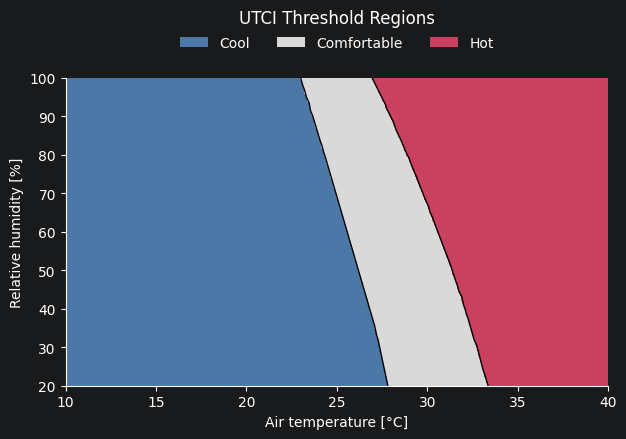

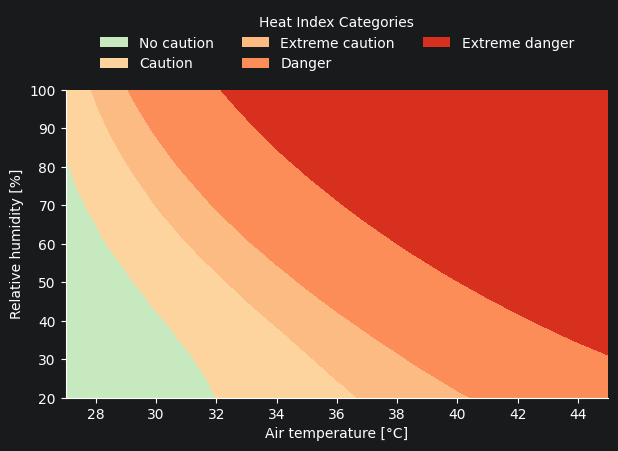

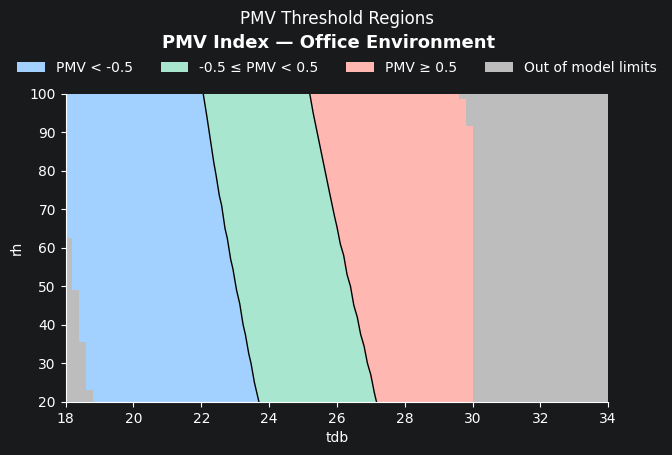

In [10]:
fig_result = (
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 34.0, resolution=0.2)
    .set_y_axis("rh", 20.0, 100.0, resolution=0.5)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(title=None)
)

# result.fig is the underlying Figure — use it for figure-level operations
fig_result.fig.suptitle(
    "PMV Index — Office Environment",
    y=1.03,
    fontsize=13,
    fontweight="bold",
)

fig_result.ax.set_title(label="PMV Threshold Regions", y=1.2)  # add title

plt.show()

## 10. Fill and Legend Artist Customization

`result.fills` is a list of `PolyCollection` artists — one per region in threshold order.
`result.legend` is the `Legend` artist (`None` when `legend=False`).

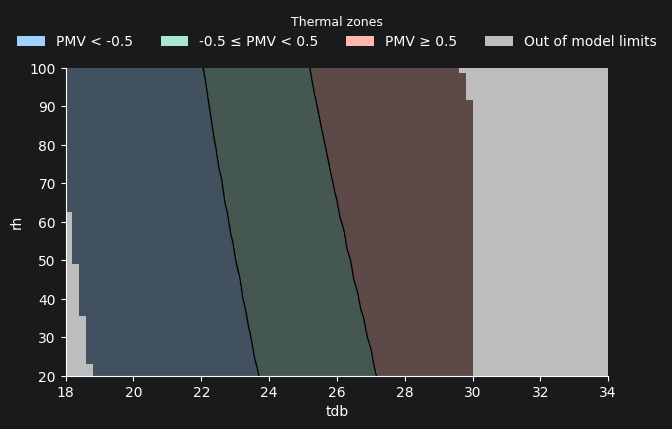

In [11]:
fills_result = (
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 34.0, resolution=0.2)
    .set_y_axis("rh", 20.0, 100.0, resolution=0.5)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot()
)

# result.fills is a list of PolyCollection — one per region (in threshold order)
# Here we dial back the outer regions and keep the neutral band brightest.
for fill, alpha in zip(fills_result.fills, [0.3, 0.6, 0.3], strict=False):
    fill.set_alpha(alpha)

# result.legend is the Legend artist (None when legend=False)
if fills_result.legend is not None:
    fills_result.legend.set_title("Thermal zones", prop={"size": 9})

plt.show()

## 11. The `tr`/`tdb` Auto-Link in `set_params`

When a model accepts both `tdb` (dry-bulb temperature) and `tr` (mean radiant
temperature), and one of them is used as an axis, `ThresholdPlot` automatically
copies its per-cell value to the other if it is **not** explicitly supplied in
`set_params`.  Supply `tr=<value>` explicitly to override this behaviour.

The side-by-side below shows the difference clearly.

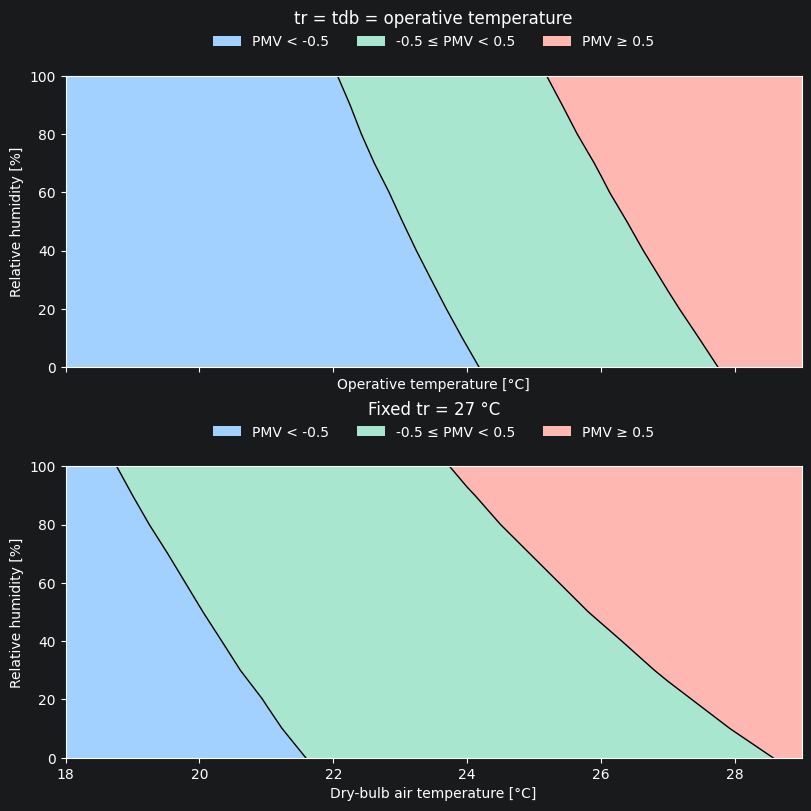

In [12]:
fig, (ax0, ax1) = plt.subplots(
    2, 1, figsize=(8, 8), constrained_layout=True, sharex=True
)

# Left: tr omitted — auto-links to tdb (tr = tdb for every grid cell)
(
    ThresholdPlot(pmv_ppd_ashrae)
    .set_x_axis("tdb", 18, 29, resolution=1)
    .set_y_axis("rh", 0.0, 100.0, resolution=10)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)  # tr omitted → auto tr = tdb
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=ax0, title="tr = tdb = operative temperature")
).ax.set(xlabel="Operative temperature [°C]", ylabel="Relative humidity [%]")

# Right: tr fixed at 27 °C regardless of the tdb axis
(
    ThresholdPlot(pmv_ppd_ashrae)
    .set_x_axis("tdb", 18, 29.0, resolution=1)
    .set_y_axis("rh", 0.0, 100.0, resolution=10)
    .set_params(
        tr=27.0, vr=0.10, met=1.2, clo=0.5, wme=0.0
    )  # tr fixed at 27 °C, limit_inputs off to show out-of-model cells
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=ax1, title="Fixed tr = 27 °C")
).ax.set(xlabel="Dry-bulb air temperature [°C]", ylabel="Relative humidity [%]")

plt.show()

## 12. The Psychrometric Chart (`PsychrometricPlot`)

The `PsychrometricPlot` class extends the standard threshold plotting capabilities specifically for psychrometric charts. It strictly enforces `tdb` (dry-bulb temperature) on the x-axis and `hr` (humidity ratio) on the y-axis.

Because standard thermal models (like PMV) require relative humidity (`rh`) rather than humidity ratio, this class automatically reverse-calculates `rh` during grid evaluation and safely masks out physically impossible regions (where RH > 100%). It also automatically renders constant relative humidity curves in the background.

The example below demonstrates how to configure and render a psychrometric chart for the PMV model.

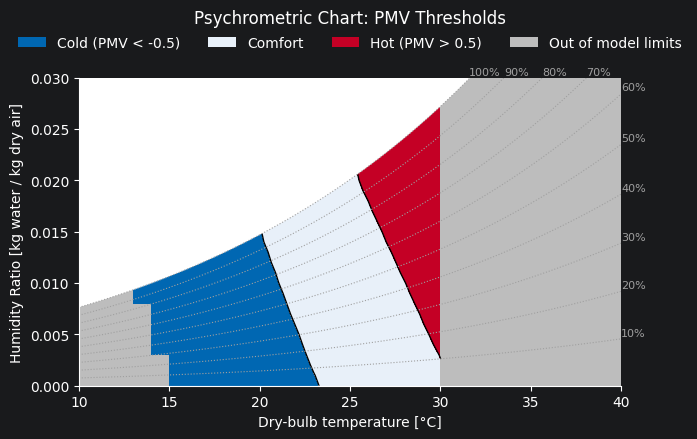

In [13]:
psy_result = (
    PsychrometricPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 10.0, 40.0, resolution=1)
    .set_y_axis("hr", 0.0, 0.030, resolution=0.001)
    .set_params(vr=0.10, met=1.2, clo=0.5, tr=25.0)
    .set_regions(
        output="pmv",
        thresholds=[-0.5, 0.5],
        labels=["Cold (PMV < -0.5)", "Comfort", "Hot (PMV > 0.5)"],
        colors=["#0067B2", "#E8F0F9", "#C40025"],
    )
    .plot(title="Psychrometric Chart: PMV Thresholds")
)

psy_result.ax.set_xlabel("Dry-bulb temperature [°C]")
psy_result.ax.set_ylabel("Humidity Ratio [kg water / kg dry air]")
plt.show()

## 13. Adaptive Comfort Chart (`AdaptivePlot`)

`AdaptivePlot` renders adaptive comfort charts following the **ASHRAE 55** or **EN 16798** standard.  The chart plots comfort bands on operative temperature (y-axis) versus prevailing mean outdoor temperature (x-axis).

Pass the model function directly (`adaptive_ashrae` or `adaptive_en`) and call `set_params(v=...)` to set the air speed.  When `v ≥ 0.6 m/s` and operative temperature exceeds 25 °C, a cooling effect shifts the **upper** boundary of each band upward.

### 13.1 — Basic ASHRAE 55 chart

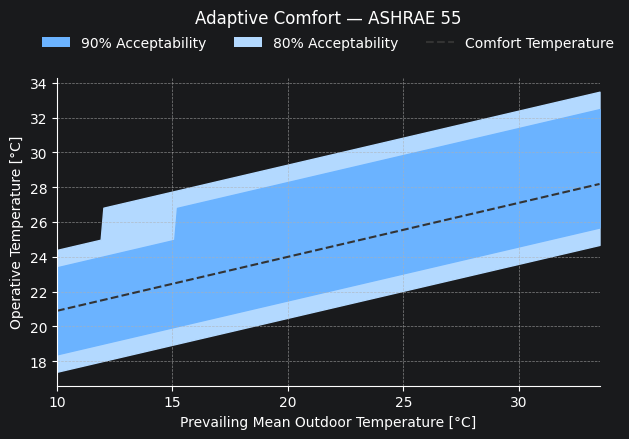

In [14]:
ashrae_result = (
    AdaptivePlot(adaptive_ashrae)
    .set_params(v=1.0)
    .plot(title="Adaptive Comfort — ASHRAE 55")
)
plt.show()

### 13.2 — EN 16798 chart with `set_regions`

`set_regions` selects which bands to display and lets you override their labels and colors.  The example below shows only Categories I and II using a custom palette.

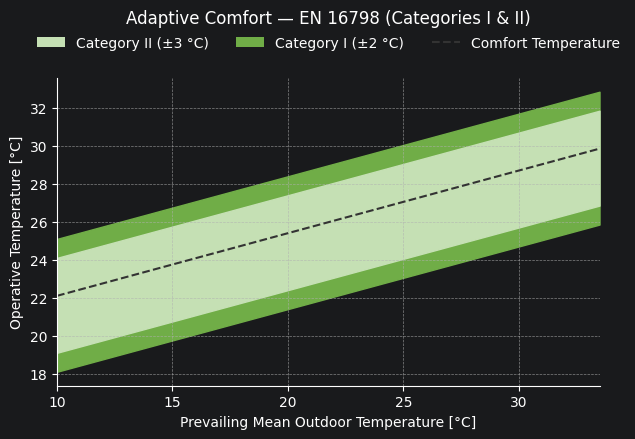

In [15]:
en_result = (
    AdaptivePlot(adaptive_en)
    .set_params(v=0.1)
    .set_regions(
        show=["cat_i", "cat_ii"],
        labels=["Category I (±2 °C)", "Category II (±3 °C)"],
        colors=["#70AD47", "#C5E0B4"],
    )
    .plot(title="Adaptive Comfort — EN 16798 (Categories I & II)")
)
plt.show()

### 13.3 — Reusable configuration with `RegionsConfig`

`RegionsConfig` lets you define a set of adaptive comfort bands once and reuse the same configuration across multiple plots.

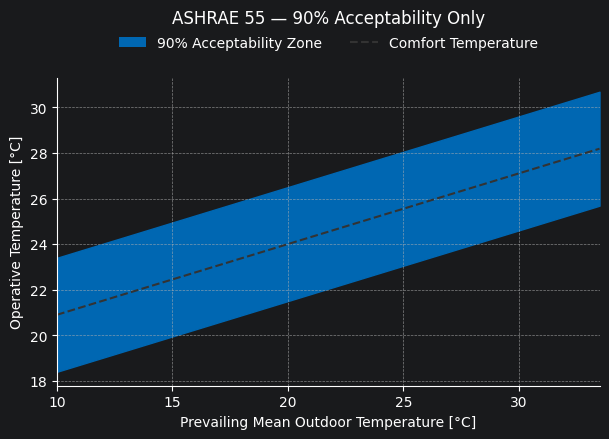

In [16]:
ashrae_config = RegionsConfig(
    show=["90"],
    labels=["90% Acceptability Zone"],
    colors=["#0067B2"],
)

ashrae_90_result = (
    AdaptivePlot(adaptive_ashrae)
    .set_params(v=0.1)
    .set_regions(show=ashrae_config)
    .plot(title="ASHRAE 55 — 90% Acceptability Only")
)
plt.show()

### 13.4 — Cooling effect: still air vs. elevated air speed

When `v ≥ 0.6 m/s` and operative temperature exceeds 25 °C, the model applies a cooling effect that shifts the **upper** boundary of each band upward.  The side-by-side below makes the difference visible.

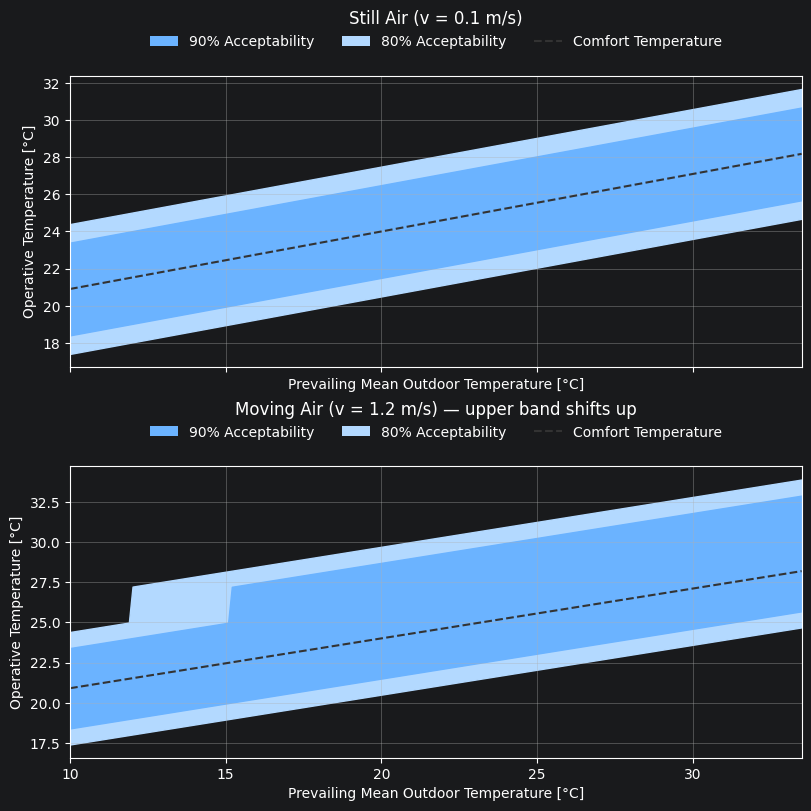

In [17]:
fig, (ax0, ax1) = plt.subplots(
    2, 1, figsize=(8, 8), constrained_layout=True, sharex=True
)

AdaptivePlot(adaptive_ashrae).set_params(v=0.1).plot(
    ax=ax0, title="Still Air (v = 0.1 m/s)"
)
AdaptivePlot(adaptive_ashrae).set_params(v=1.2).plot(
    ax=ax1, title="Moving Air (v = 1.2 m/s) — upper band shifts up"
)

plt.show()